SIMPLE LINEAR REGRESSION

Use scikit-learn to implement simple linear regression to create, train, and test a linear regression model on real data.

OBJECTIVES

To use  Simple Linear Regression to solve real word problem, such as predicting the likelyhood of flood in Nigeria.

Import needed python tools (Packages)

For this analysis, I will be using the following tools:
NumPy
Pandas
Matplotlib
Scikit-learn

To avoid issues importing these libraries, I will execute the following cell to ensure they are available. I used %pip, instead of the common !pip to ensure that the packages are not installed into wrong environments

In [1]:
%pip install numpy
%pip install pandas
%pip install scikit-learn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Now I can import these libraries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

LOAD DATA

I saved the dataset for this analysis in Google Drive and the URL is as shown below. The URL can be used directly with the Pandas library to load the dataset

In [3]:
url = "https://drive.google.com/uc?export=download&id=1wu3ZDXwla-FZSuuQ9Vndn_CgtUDB-NbW"

In [4]:
df=pd.read_csv(url)

In [5]:
# verify successful load with some randomly selected records
df.sample(5)

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
10986,3,8,11,9,4,5,5,2,5,6,...,4,2,6,2,8,5,5,3,2,0.515
24687,7,4,5,4,4,6,4,2,9,5,...,4,7,1,7,4,8,5,9,5,0.530
6082,6,3,9,5,3,5,3,5,7,3,...,8,4,5,7,4,8,3,4,6,0.515
13830,3,5,2,4,2,3,1,5,6,3,...,5,4,5,3,6,5,8,4,3,0.405
9259,4,5,8,1,4,4,2,5,2,5,...,6,5,4,3,8,6,3,10,4,0.485


UNDERSTAND THE DATA

### Flood.csv
I used a Kaggle Flood Prediction Dataset, **`Flood.csv`**, which contains  50000 rows and 21 columns of raw data.
The dataset includes 21 numeric variables such as 
1. MonsoonIntensity, 
2. TopographyDrainage, 
3. RiverManagement, 
4. Deforestation, 
5. Urbanization, 
6. ClimateChange, 
7. DamsQuality, 
8. Siltation, 
9. AgriculturalPractices, 
10. Encroachments, 
11. IneffectiveDisasterPreparedness, 
12. DrainageSystems, 
13. CoastalVulnerability,
14. Landslides, 
15. Watersheds, 
16. DeterioratingInfrastructure, 
17. PopulationScore, 
18. WetlandLoss, 
19. InadequatePlanning, 
20. PoliticalFactors, and 
21. FloodProbability. 
[Dataset source]: https://drive.google.com/file/d/1wu3ZDXwla-FZSuuQ9Vndn_CgtUDB-NbW/view?usp=sharing

However, for a Simple Linear Regression, the rule is that we I can only use ONE single clue (feature) to predict the flood target. Therefore, I will make use of the MonsoonIntensity as the ONE single clue (feature) and the FloodProbability to predict the flood target.

EXPLORING THE DATA

First consider a statistical summary of the data.

In [6]:
df.describe()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000


The first 20 columns are whole numbers (integers like 5, 6, 12), which likely represent environmental clues like daily rainfall, river levels, or soil moisture.
The last column contains decimals (like 0.64, 0.5211), is perfect for a Regression Target (likely representing a continuous Flood Risk Index, probability, or water level).

SELECT FEATURES

Select a few features that might be indicative of the possibility of flood to explore more.

In [7]:
cdf = df[['MonsoonIntensity','ClimateChange','TopographyDrainage','FloodProbability']]
cdf.sample(9)

,MonsoonIntensity,ClimateChange,TopographyDrainage,FloodProbability
13855,2,4,4,0.480
1353,6,9,5,0.495
25650,3,3,8,0.545
37534,5,3,6,0.525
26729,3,10,7,0.570
13945,7,5,7,0.520
26350,8,4,4,0.465
4537,5,6,4,0.510
26552,4,6,6,0.500


VISUALIZE FEATURES

Consider the histogram for each of these features

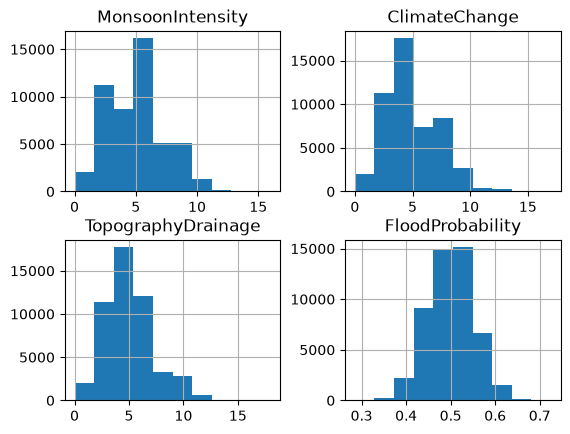

In [8]:
viz = cdf[['MonsoonIntensity','ClimateChange','TopographyDrainage','FloodProbability']]
viz.hist()
plt.show()

Display some scatter plots of these features against FloodProbability, to see how linear their relationships are.

The linear their relationships between MonsoonIntensity and FloodProbability

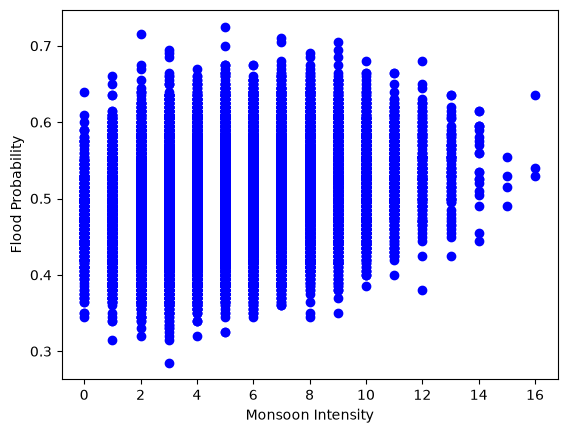

<Figure size 640x480 with 0 Axes>

In [9]:
plt.scatter(cdf.MonsoonIntensity, cdf.FloodProbability,  color='blue')
plt.xlabel("Monsoon Intensity")
plt.ylabel("Flood Probability")
plt.show()
plt.savefig('scatter_plot1.png', dpi=300, bbox_inches='tight')

The linear their relationships between ClimateChange and FloodProbability.

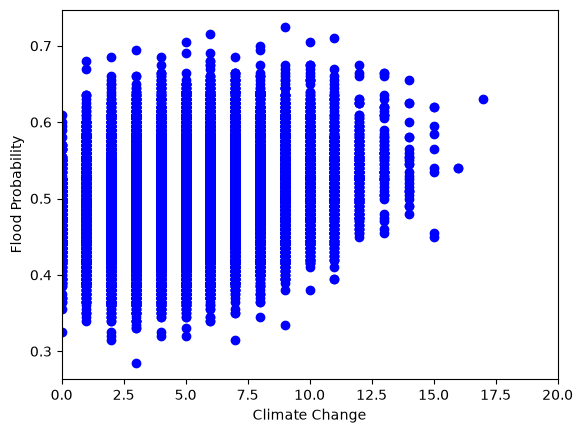

<Figure size 640x480 with 0 Axes>

In [10]:
plt.scatter(cdf.ClimateChange, cdf.FloodProbability,  color='blue')
plt.xlabel("Climate Change")
plt.ylabel("Flood Probability")
plt.xlim(0,20)
plt.show()
plt.savefig('scatter_plot2.png', dpi=300, bbox_inches='tight')

MACHINE LEARNING

EXTRACTING THE INPUT FEATURE AND LABELS FROM THE DATASET. 

The process by extracting the input feature and target output variables, X and y, from the dataset.

In [11]:
X = cdf.MonsoonIntensity.to_numpy()
y = cdf.FloodProbability.to_numpy()

CREATE, TRAIN AND TEST DATASETS

Next  is to split the dataset into mutually exclusive training and testing sets. I will train a simple linear regression model on the training set and estimate its ability to generalize to unseen data by using it to make predictions on the unseen testing data.
    
Since the outcome of each data point is part of the testing data, therefore, I have a means of evaluating the out-of-sample accuracy of the model.

Now, I will randomly split the data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing. The fraction to use here mostly depends on the size of the data, but typical testing sizes range from 20% to 30%. The smaller the data, the larger the training set needs to be because it's easier to find spurious patterns in smaller data. The downside is that the evaluation of generalizability will have less reliability. Bigger is better when it comes to data.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

The outputs are one-dimensional NumPy arrays or vectors

In [13]:
type(X_train), np.shape(X_train), np.shape(X_train)

(numpy.ndarray, (40000,), (40000,))

BUILD A SIMPLE LINEAR REGRESSION MODEL

I am using scikit-learn to build the model as follows. See [Scikit-Learn Linear Regression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) for more information about the linear model predictor object.

In [14]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model on the training data
# X_train is a 1-D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features).
# So we need to reshape it. We can let it infer the number of observations using '-1'.
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print ('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressor.intercept_)

Coefficients:  0.004924073347406248
Intercept:  0.47496522566049354


Here the Coefficient and Intercept are the regression parameters determined by the model.
They define the slope and intercept of the 'best-fit' line to the training data.


VISUALIZE MODEL OUTPUTS

We can visualize the goodness-of-fit of the model to the training data by plotting the fitted line over the data.

The regression model is the line given by y = [intercept + (coefficient * x)].

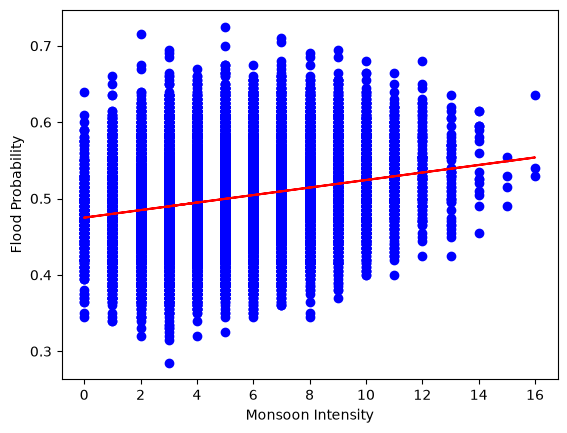

In [15]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Monsoon Intensity")
plt.ylabel("Flood Probability")
plt.savefig('scatter_plot3.png', dpi=300, bbox_inches='tight')

MODEL EVALUATION

We can now compare the actual values and predicted values to calculate the accuracy of a regression model. Evaluation metrics play a key role in the development of a model, as they provide insight into areas that require improvement.

There are different model evaluation metrics, let's use MSE here to calculate the accuracy of our model based on the test set:
    1. Mean Absolute Error: It is the mean of the absolute value of the errors. This is the easiest of the metrics to understand since it’s just an average error.
    
    2. Mean Squared Error (MSE): MSE is the mean of the squared error. In fact, it's the metric used by the model to find the best fit line, and for that reason, it is also called the residual sum of squares.

    3. Root Mean Squared Error (RMSE). RMSE simply transforms the MSE into the same units as the variables being compared, which can make it easier to interpret.
    
    4. R2-Score is not an error but rather a popular metric used to estimate the performance of your regression model. It represents how close the data points are to the fitted regression line. The higher the R2-Score value, the better the model fits your data. The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).

In [16]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

# Calculate the metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 1. This still prints the results in your notebook console
print("Mean absolute error: %.2f" % mae)
print("Mean squared error: %.2f" % mse)
print("Root mean squared error: %.2f" % rmse)
print("R2-score: %.2f" % r2)

# 2. This code saves the results to a text file in your project folder
with open("evaluation_results.txt", "w") as f:
    f.write("--- Model Evaluation Results ---\n")
    f.write("Mean absolute error: %.2f\n" % mae)
    f.write("Mean squared error: %.2f\n" % mse)
    f.write("Root mean squared error: %.2f\n" % rmse)
    f.write("R2-score: %.2f\n" % r2)

Mean absolute error: 0.04
Mean squared error: 0.00
Root mean squared error: 0.05
R2-score: 0.06


Plotting the regression model result over the test data instead of the training data and visually evaluate whether the result is good. (Training Dataset = 20%; Test Dataset = 80%)

CREATE, TRAIN AND TEST DATA 2

In [17]:
from sklearn.model_selection import train_test_split

# Changed test_size to 0.8 to give 80% to the test set and 20% to the training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

BUILD A SIMPLE LINEAR MODEL 2

In [18]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model on the training data
# X_train is a 1-D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features).
# So we need to reshape it. We can let it infer the number of observations using '-1'.
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print ('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressor.intercept_)

Coefficients:  0.004812868183889725
Intercept:  0.47592304743650043


VISUALIZE MODEL OUTPUTS

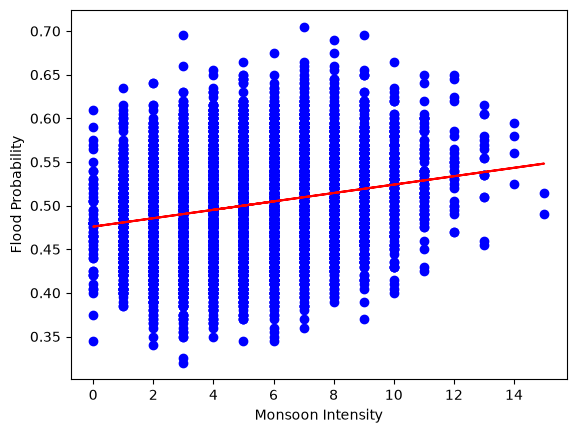

In [19]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Monsoon Intensity")
plt.ylabel("Flood Probability")
plt.savefig('scatter_plot4.png', dpi=300, bbox_inches='tight')

MODEL EVALUATION

In [20]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions using the new test set
y_pred = regressor.predict(X_test.reshape(-1, 1))

# Calculate the new metrics
mae_20_80 = mean_absolute_error(y_test, y_pred)
mse_20_80 = mean_squared_error(y_test, y_pred)
rmse_20_80 = np.sqrt(mse_20_80)
r2_20_80 = r2_score(y_test, y_pred)

# 5. Print the results in your notebook console
print("--- 20 Train / 80 Test Results ---")
print("Mean absolute error: %.2f" % mae_20_80)
print("Mean squared error: %.2f" % mse_20_80)
print("Root mean squared error: %.2f" % rmse_20_80)
print("R2-score: %.2f" % r2_20_80)

# 6. Save the results to a new separate text file
with open("evaluation_results2_20_80.txt", "w") as f:
    f.write("--- Model Evaluation Results (20% Train / 80% Test) ---\n")
    f.write("Mean absolute error: %.2f\n" % mae_20_80)
    f.write("Mean squared error: %.2f\n" % mse_20_80)
    f.write("Root mean squared error: %.2f\n" % rmse_20_80)
    f.write("R2-score: %.2f\n" % r2_20_80)


--- 20 Train / 80 Test Results ---
Mean absolute error: 0.04
Mean squared error: 0.00
Root mean squared error: 0.05
R2-score: 0.05


Created by Obinna Nwosu C